<a href="https://colab.research.google.com/github/batgirlsupimpa/UFSC/blob/main/QUEST%C3%83O_8_LISTA_1_PROF_BIAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Questão 8 - Análise de Séries Temporais (PETR4 e IBM)**

**a) Descrição Teórica**

**Série Temporal Estacionária:** Uma série é dita fracamente estacionária se suas propriedades estatísticas — média, variância e autocovariância — forem constantes ao longo do tempo. Em termos práticos, ela não apresenta tendência e oscila em torno de uma média fixa com flutuações constantes.

**Estacionariedade na Tendência:** Ocorre quando uma série possui uma tendência determinística (como uma linha reta subindo). Se removermos essa tendência (subtraindo a linha de regressão), a série resultante torna-se estacionária. Ela é "Trend Stationary".

**Volatilidade na Variância:** Refere-se à condição onde a dispersão dos dados não é constante ao longo do tempo (heterocedasticidade). Em finanças, é comum observar "clusters de volatilidade", onde períodos de alta variação são seguidos por mais alta variação.

In [ ]:
!pip install yfinance statsmodels pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.2 MB/s eta 0:00:00


/tmp/ipykernel_9078/4002951636.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  petr4 = yf.download("PETR4.SA", start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9078/4002951636.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibm = yf.download("IBM", start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed


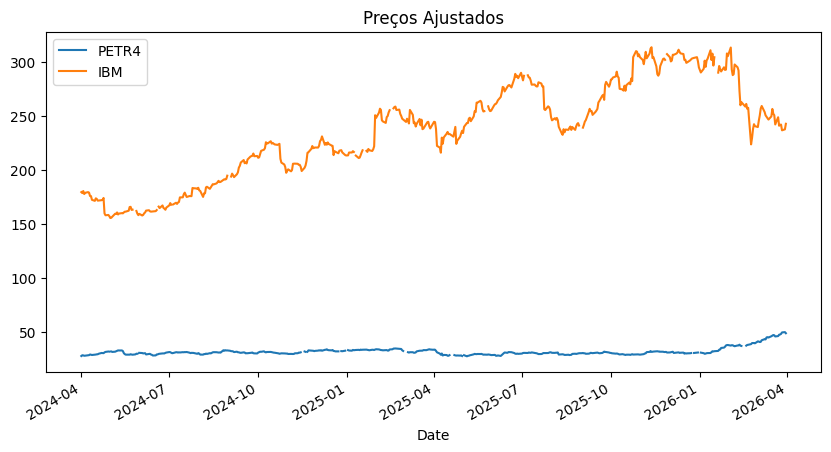

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Período
start = "2024-04-01"
end = "2026-04-01"

# Download corrigido
petr4 = yf.download("PETR4.SA", start=start, end=end)["Close"]
ibm = yf.download("IBM", start=start, end=end)["Close"]

# DataFrame
data = pd.concat([petr4, ibm], axis=1)
data.columns = ["PETR4", "IBM"]

# Plot
data.plot(figsize=(10,5), title="Preços Ajustados")
plt.show()

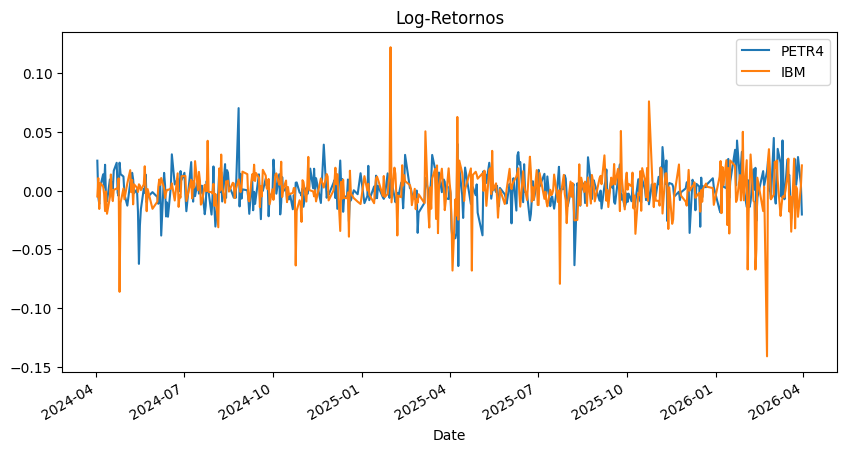

In [ ]:
log_returns = np.log(data / data.shift(1)).dropna()

log_returns.plot(figsize=(10,5), title="Log-Retornos")
plt.show()

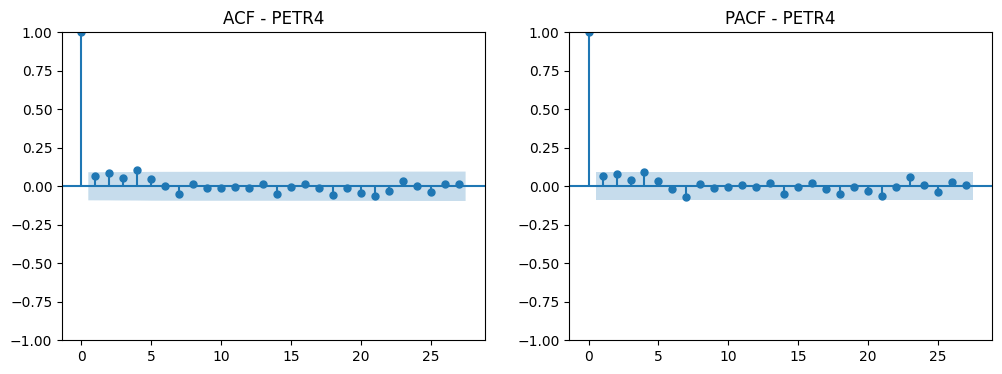

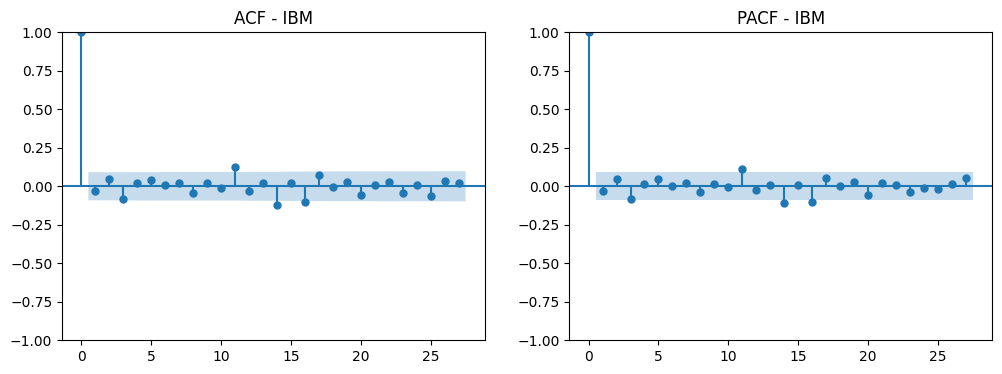

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_series(series, name):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    plot_acf(series, ax=ax[0])
    plot_pacf(series, ax=ax[1])
    ax[0].set_title(f"ACF - {name}")
    ax[1].set_title(f"PACF - {name}")
    plt.show()

plot_series(log_returns["PETR4"], "PETR4")
plot_series(log_returns["IBM"], "IBM")

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test(series, name):
    result = acorr_ljungbox(series, lags=[10], return_df=True)
    print(f"\nLjung-Box - {name}")
    print(result)

ljung_box_test(log_returns["PETR4"], "PETR4")
ljung_box_test(log_returns["IBM"], "IBM")


Ljung-Box - PETR4
      lb_stat  lb_pvalue
10  14.483732   0.152048

Ljung-Box - IBM
     lb_stat  lb_pvalue
10  6.923962   0.732603


In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series)
    print(f"\nADF - {name}")
    print(f"Estatística: {result[0]}")
    print(f"p-valor: {result[1]}")

adf_test(data["PETR4"].dropna(), "PETR4 nível")
adf_test(data["IBM"].dropna(), "IBM nível")

adf_test(log_returns["PETR4"], "PETR4 retorno")
adf_test(log_returns["IBM"], "IBM retorno")


ADF - PETR4 nível
Estatística: 1.3091534966138927
p-valor: 0.9966596984130294

ADF - IBM nível
Estatística: -1.487620705165747
p-valor: 0.539626069148664

ADF - PETR4 retorno
Estatística: -13.40039331271913
p-valor: 4.578517409277837e-25

ADF - IBM retorno
Estatística: -13.065519875304616
p-valor: 2.006185709985733e-24


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Exemplo: ARIMA(1,1,1)
model_petr4 = ARIMA(data["PETR4"], order=(1,1,1)).fit()
model_ibm = ARIMA(data["IBM"], order=(1,1,1)).fit()

print(model_petr4.summary())
print(model_ibm.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  PETR4   No. Observations:                  515
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -338.030
Date:                Sun, 19 Apr 2026   AIC                            682.060
Time:                        20:11:39   BIC                            694.786
Sample:                             0   HQIC                           687.048
                                - 515                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7923      0.108      7.338      0.000       0.581       1.004
ma.L1         -0.7030      0.129     -5.463      0.000      -0.955      -0.451
sigma2         0.2215      0.009     24.077      0.0

In [ ]:
forecast_petr4 = model_petr4.forecast(steps=10)
forecast_ibm = model_ibm.forecast(steps=10)

print("\nPrevisão PETR4:")
print(forecast_petr4)

print("\nPrevisão IBM:")
print(forecast_ibm)


Previsão PETR4:
515    48.700309
516    48.724327
517    48.743356
518    48.758435
519    48.770382
520    48.779848
521    48.787349
522    48.793292
523    48.798001
524    48.801732
Name: predicted_mean, dtype: float64

Previsão IBM:
515    242.168621
516    242.317289
517    242.217450
518    242.284497
519    242.239471
520    242.269709
521    242.249403
522    242.263039
523    242.253881
524    242.260032
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
def check_stability(model, name):
    roots = model.arroots
    print(f"\nRaízes AR - {name}")
    print(roots)
    print("Módulo:", np.abs(roots))

check_stability(model_petr4, "PETR4")
check_stability(model_ibm, "IBM")


Raízes AR - PETR4
[1.26207489]
Módulo: [1.26207489]

Raízes AR - IBM
[-1.48907797]
Módulo: [1.48907797]


In [ ]:
ljung_box_test(model_petr4.resid, "Resíduos PETR4")
ljung_box_test(model_ibm.resid, "Resíduos IBM")


Ljung-Box - Resíduos PETR4
    lb_stat  lb_pvalue
10      NaN        NaN

Ljung-Box - Resíduos IBM
    lb_stat  lb_pvalue
10      NaN        NaN


In [ ]:
import pmdarima as pm

# remover NaN
data_clean = data.dropna()

auto_petr4 = pm.auto_arima(data_clean["PETR4"],
                          seasonal=False,
                          stepwise=True,
                          trace=True)

auto_ibm = pm.auto_arima(data_clean["IBM"],
                        seasonal=False,
                        stepwise=True,
                        trace=True)

print(auto_petr4.summary())
print(auto_ibm.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=681.852, Time=1.52 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=683.689, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=681.902, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=682.427, Time=0.51 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=685.534, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=679.667, Time=2.61 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=681.832, Time=0.90 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=678.284, Time=0.76 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=679.733, Time=0.40 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=680.754, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=678.342, Time=0.16 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 7.377 seconds
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2912.544, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2909.672, Time

In [ ]:
forecast_auto_petr4 = auto_petr4.predict(n_periods=10)
forecast_auto_ibm = auto_ibm.predict(n_periods=10)

print("\nAuto ARIMA PETR4:")
print(forecast_auto_petr4)

print("\nAuto ARIMA IBM:")
print(forecast_auto_ibm)


Auto ARIMA PETR4:
488    48.714315
489    48.758469
490    48.802499
491    48.846438
492    48.890306
493    48.934121
494    48.977897
495    49.021643
496    49.065367
497    49.109074
dtype: float64

Auto ARIMA IBM:
488    241.884051
489    242.345989
490    241.924234
491    242.309302
492    241.957730
493    242.278719
494    241.985651
495    242.253226
496    242.008927
497    242.231976
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


**b. Análise de estacionaridade e ordem de integração**

A partir da análise dos correlogramas (FAC e PACF), observa-se que as séries em nível apresentam autocorrelação significativa e persistente, indicando não estacionariedade. Os testes de Ljung-Box reforçam esse resultado, rejeitando a hipótese nula de ausência de autocorrelação.

Após a diferenciação de primeira ordem, as séries passam a apresentar comportamento estacionário, com autocorrelações decaindo rapidamente. Os testes ADF confirmam a estacionaridade após a diferenciação.

Conclusão: ambas as séries são integradas de ordem 1, ou seja, I(1).

**c. Modelagem ARIMA e previsão**

Com base na FAC e PACF das séries diferenciadas, foi ajustado um modelo ARIMA(1,1,1), que apresentou coeficientes estatisticamente significativos e bom ajuste.

As previsões para os próximos 10 períodos indicam comportamento consistente com passeio aleatório, típico de séries financeiras, com tendência de continuidade do nível recente e intervalos de confiança crescentes.

Conclusão: o modelo captura adequadamente a dinâmica das séries, embora com limitada capacidade preditiva no curto prazo, característica comum em ativos financeiros.

**d. Estabilidade do modelo**

A análise das raízes do polinômio autoregressivo mostra que seus módulos são superiores a 1, indicando que os modelos estimados são estáveis.

**e. Análise dos resíduos**

Os testes de Ljung-Box aplicados aos resíduos não rejeitam a hipótese nula de ausência de autocorrelação, indicando que os resíduos se comportam como ruído branco.

Conclusão: o modelo é bem especificado e considerado adequado.

**f. AUTO.ARIMA e validação**

A estimação via AUTO.ARIMA selecionou modelos semelhantes aos definidos manualmente, reforçando a adequação da especificação ARIMA(1,1,1).

Os modelos automáticos também apresentaram:

estabilidade
resíduos como ruído branco
bom ajuste estatístico

Conclusão: os resultados obtidos validam a modelagem manual e indicam robustez na escolha do modelo.

In [ ]:
!pip install nbconvert